## 1. Imports

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

import torch
from torch.utils.data import DataLoader

from paths import TRAIN_PATH, VAL_PATH, TEST_PATH, CHECKPOINT_DIR

from amr_dataset import AMRDataset
from utils import (get_device, load_best_model, high_snr_confusion)

from viz import (plot_training_curves,
                 plot_accuracy_vs_snr_comparison,
                 accuracy_vs_snr_table,
                 collect_predictions,
                 plot_confusion_matrix,
                 plot_accuracy_vs_snr,
                 accuracy_vs_snr_table)

%matplotlib inline

## 2. Device Check and File Loading Checks

In [2]:
device = get_device()
print(f"Using device: {device}")

for name, p in [("train", TRAIN_PATH), ("val", VAL_PATH), ("test", TEST_PATH)]:
    print(f"{name}: {p} exists={p.exists()}")

Using device: cuda
train: /home/courier/luebeck/lub-amr/data/splits/train.h5 exists=True
val: /home/courier/luebeck/lub-amr/data/splits/val.h5 exists=True
test: /home/courier/luebeck/lub-amr/data/splits/test.h5 exists=True


## 3. Sanity Check for loading one batch

In [3]:
train_ds = AMRDataset(TRAIN_PATH, normalize="per_sample")
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

iq, mod_label, snr, domain = next(iter(train_loader))

print("iq shape:", iq.shape)
print("mod_label shape:", mod_label.shape)
print("snr shape:", snr.shape)
print("domain shape:", domain.shape)

iq shape: torch.Size([256, 2, 1024])
mod_label shape: torch.Size([256])
snr shape: torch.Size([256])
domain shape: torch.Size([256])


## 4. Baseline Training

In [4]:
from train import train_model
from models import BaselineCNN

history = train_model(
    model_cls   = BaselineCNN,
    run_name    = "baseline_pooled",
    epochs      = 20,
    batch_size  = 256,
    lr          = 1e-3,
    normalize   = "per_sample",
)

Using device: cuda
[baseline_pooled] epoch   1/20 train_loss=1.1400 train_acc=0.4525 val_loss=1.0961 val_acc=0.4624 (8.6s)
  -> saved new best checkpoint (val_acc=0.4624)
[baseline_pooled] epoch   2/20 train_loss=1.0190 train_acc=0.5097 val_loss=1.1813 val_acc=0.4444 (8.2s)
[baseline_pooled] epoch   3/20 train_loss=0.9812 train_acc=0.5254 val_loss=1.1212 val_acc=0.4394 (7.3s)
[baseline_pooled] epoch   4/20 train_loss=0.9528 train_acc=0.5361 val_loss=0.9986 val_acc=0.5097 (8.2s)
  -> saved new best checkpoint (val_acc=0.5097)
[baseline_pooled] epoch   5/20 train_loss=0.9273 train_acc=0.5477 val_loss=1.1176 val_acc=0.4656 (8.1s)
[baseline_pooled] epoch   6/20 train_loss=0.9054 train_acc=0.5591 val_loss=1.0459 val_acc=0.4830 (8.1s)
[baseline_pooled] epoch   7/20 train_loss=0.8836 train_acc=0.5687 val_loss=1.0534 val_acc=0.5262 (7.1s)
  -> saved new best checkpoint (val_acc=0.5262)
[baseline_pooled] epoch   8/20 train_loss=0.8663 train_acc=0.5786 val_loss=0.9492 val_acc=0.5525 (8.2s)
  -> 

## 5. Plotting 

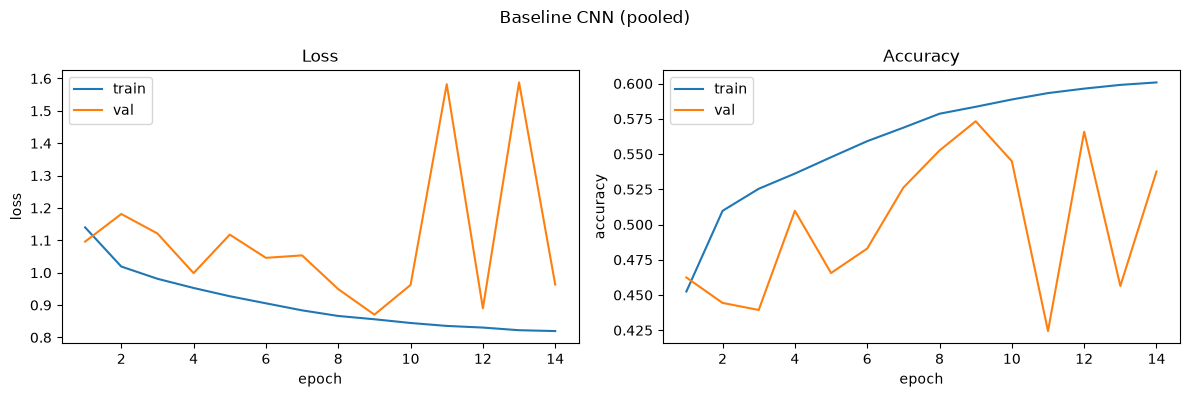

In [5]:
plot_training_curves(history, title = "Baseline CNN (pooled)");

## 6. Getting the best points from checkpoint dir

In [6]:
checkpoint_path = CHECKPOINT_DIR / "baseline_pooled_best.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

model = BaselineCNN().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']}, val_acc={checkpoint['val_acc']:.4f}")


Loaded checkpoint from epoch 9, val_acc=0.5732


## 7. Verification of test size

In [7]:
test_ds = AMRDataset(TEST_PATH, normalize="per_sample")
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

print(f"Test set size: {len(test_ds)}")

Test set size: 16480


## 8. Overall test accuracy

In [8]:
mod_true, mod_pred, snr, domain = collect_predictions(model, test_loader, device)

print("Overall test accuracy:", (mod_true == mod_pred).mean())

Overall test accuracy: 0.5722087378640777


## 9. Confusion Matrix

<Axes: title={'center': 'Baseline CNN (pooled) — Test Confusion Matrix'}, xlabel='Predicted', ylabel='True'>

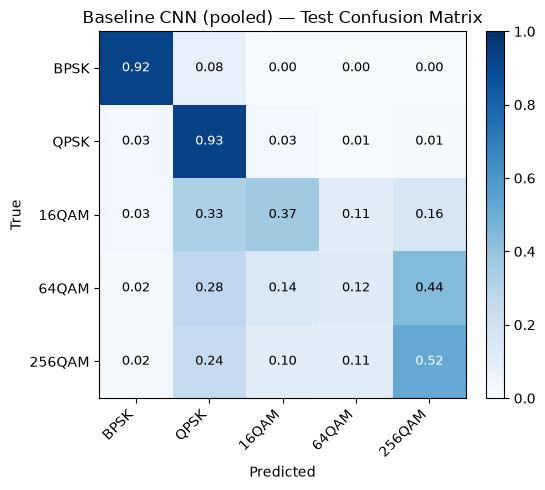

In [9]:
plot_confusion_matrix(mod_true, mod_pred, title="Baseline CNN (pooled) — Test Confusion Matrix")

## 10. Accuracy vs SNR

<Axes: title={'center': 'Baseline CNN (pooled) — Accuracy vs SNR'}, xlabel='SNR (dB)', ylabel='Accuracy'>

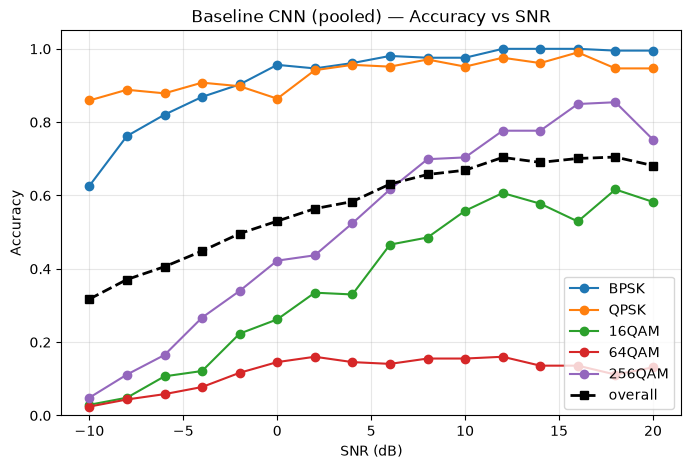

In [10]:
plot_accuracy_vs_snr(mod_true, mod_pred, snr, title="Baseline CNN (pooled) — Accuracy vs SNR")

## 10.5 Trying to debug the bad performance 

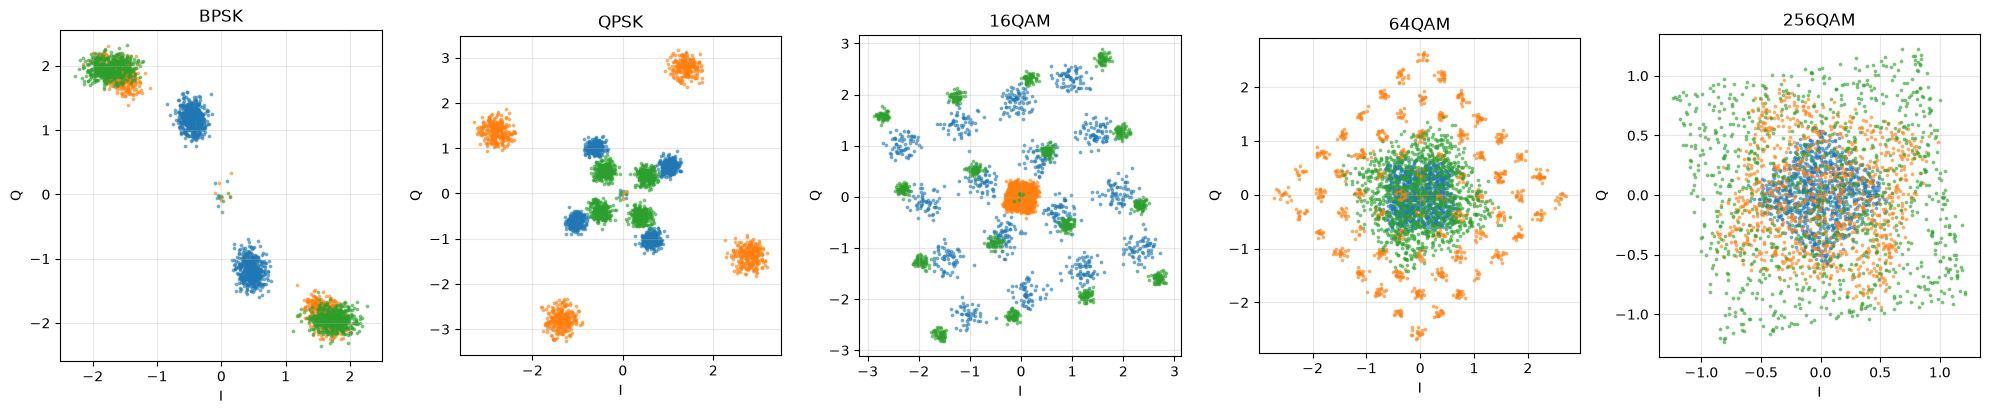

In [11]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from paths import TRAIN_PATH

MOD_NAMES = ['BPSK', 'QPSK', '16QAM', '64QAM', '256QAM']

with h5py.File(TRAIN_PATH, "r") as f:
    data = f["Data"][:]
    mods = f["Mods"][:].argmax(axis=1)
    snrs = f["SNRs"][:]

high_snr_mask = snrs >= 15

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, name in enumerate(MOD_NAMES):
    mask = high_snr_mask & (mods == i)
    idx = np.where(mask)[0][:3]  # first 3 high-SNR samples of this class
    for j in idx:
        row = data[j]
        axes[i].scatter(row.real, row.imag, s=3, alpha=0.5)
    axes[i].set_title(name)
    axes[i].set_xlabel("I")
    axes[i].set_ylabel("Q")
    axes[i].set_aspect("equal")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Baseline Comparison (RMa only)

In [12]:
history_rma = train_model(
    model_cls      = BaselineCNN,
    run_name       = "baseline_rma_only",
    epochs         = 20,
    batch_size     = 256,
    lr             = 1e-3,
    normalize      = "per_sample",
    domain_filter  = 0,  # Rma
)

Using device: cuda
[baseline_rma_only] epoch   1/20 train_loss=1.1447 train_acc=0.4511 val_loss=1.0683 val_acc=0.4836 (7.7s)
  -> saved new best checkpoint (val_acc=0.4836)
[baseline_rma_only] epoch   2/20 train_loss=1.0195 train_acc=0.5088 val_loss=1.0336 val_acc=0.4945 (8.1s)
  -> saved new best checkpoint (val_acc=0.4945)
[baseline_rma_only] epoch   3/20 train_loss=0.9884 train_acc=0.5226 val_loss=1.0343 val_acc=0.4857 (8.2s)
[baseline_rma_only] epoch   4/20 train_loss=0.9661 train_acc=0.5295 val_loss=0.9941 val_acc=0.5200 (7.3s)
  -> saved new best checkpoint (val_acc=0.5200)
[baseline_rma_only] epoch   5/20 train_loss=0.9437 train_acc=0.5394 val_loss=0.9342 val_acc=0.5292 (8.4s)
  -> saved new best checkpoint (val_acc=0.5292)
[baseline_rma_only] epoch   6/20 train_loss=0.9218 train_acc=0.5497 val_loss=1.0757 val_acc=0.4669 (8.2s)
[baseline_rma_only] epoch   7/20 train_loss=0.9003 train_acc=0.5615 val_loss=1.2126 val_acc=0.4925 (8.2s)
[baseline_rma_only] epoch   8/20 train_loss=0.8

## 12. Plotting for RMa Only

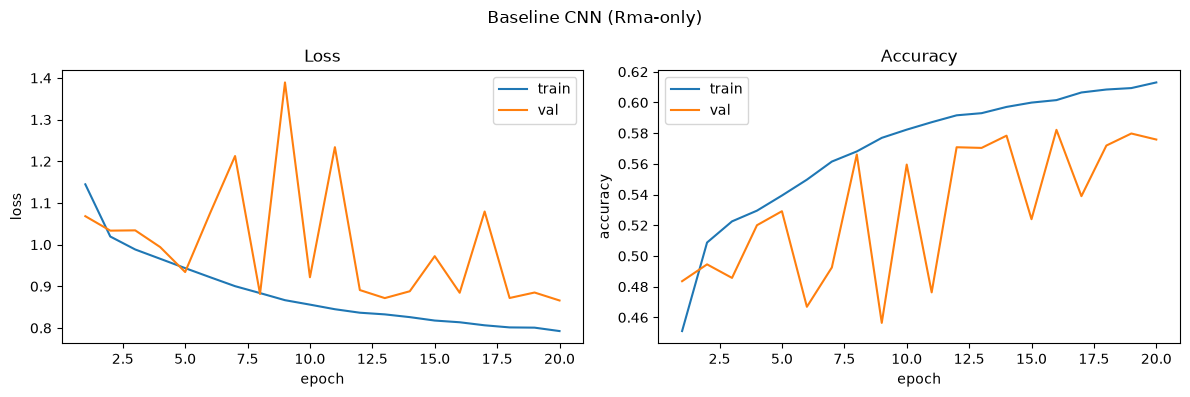

In [13]:
plot_training_curves(history_rma, title="Baseline CNN (Rma-only)");

## 13. Baseline Comparison (UMi only)

In [14]:
history_umi = train_model(
    model_cls      = BaselineCNN,
    run_name       = "baseline_umi_only",
    epochs         = 20,
    batch_size     = 256,
    lr             = 1e-3,
    normalize      = "per_sample",
    domain_filter  = 1,  # Umi
)

Using device: cuda
[baseline_umi_only] epoch   1/20 train_loss=1.1536 train_acc=0.4421 val_loss=1.0910 val_acc=0.4501 (8.2s)
  -> saved new best checkpoint (val_acc=0.4501)
[baseline_umi_only] epoch   2/20 train_loss=1.0235 train_acc=0.5071 val_loss=1.0305 val_acc=0.4946 (8.2s)
  -> saved new best checkpoint (val_acc=0.4946)
[baseline_umi_only] epoch   3/20 train_loss=0.9896 train_acc=0.5212 val_loss=1.2446 val_acc=0.4472 (8.2s)
[baseline_umi_only] epoch   4/20 train_loss=0.9645 train_acc=0.5314 val_loss=1.0275 val_acc=0.4938 (7.3s)
[baseline_umi_only] epoch   5/20 train_loss=0.9411 train_acc=0.5397 val_loss=0.9869 val_acc=0.5036 (8.1s)
  -> saved new best checkpoint (val_acc=0.5036)
[baseline_umi_only] epoch   6/20 train_loss=0.9212 train_acc=0.5484 val_loss=1.1080 val_acc=0.4485 (8.1s)
[baseline_umi_only] epoch   7/20 train_loss=0.9008 train_acc=0.5603 val_loss=0.9972 val_acc=0.5333 (8.3s)
  -> saved new best checkpoint (val_acc=0.5333)
[baseline_umi_only] epoch   8/20 train_loss=0.8

## 14. Plotting for UMi Only

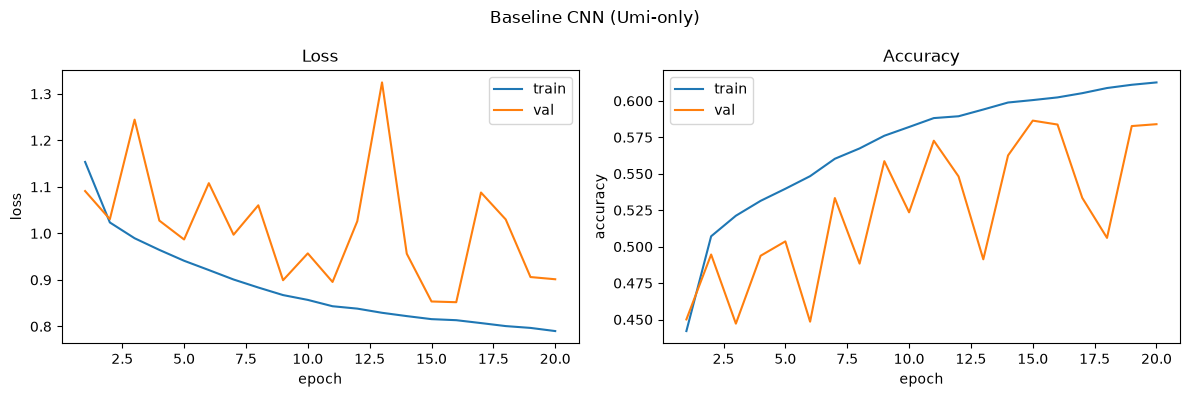

In [15]:
plot_training_curves(history_umi, title="Baseline CNN (Umi-only)");

## 15. Load RMa only and UMi Only for best checkpoints

In [19]:
model_rma = load_best_model("baseline_rma_only", device=device)
model_umi = load_best_model("baseline_umi_only", device=device)

Loaded baseline_rma_only: epoch 16, val_acc=0.5822
Loaded baseline_umi_only: epoch 15, val_acc=0.5865


## 16. Evaluation of all three on the same fixed test.h5

In [20]:
results = {
    "pooled":   collect_predictions(model,     test_loader, device)[:3],
    "rma_only": collect_predictions(model_rma, test_loader, device)[:3],
    "umi_only": collect_predictions(model_umi, test_loader, device)[:3],
}

for label, (mt, mp, _) in results.items():
    print(f"{label}: overall test accuracy = {(mt == mp).mean():.4f}")

pooled: overall test accuracy = 0.5722
rma_only: overall test accuracy = 0.5816
umi_only: overall test accuracy = 0.5872


## 17. Accuracy vs SNR - baseline comparison

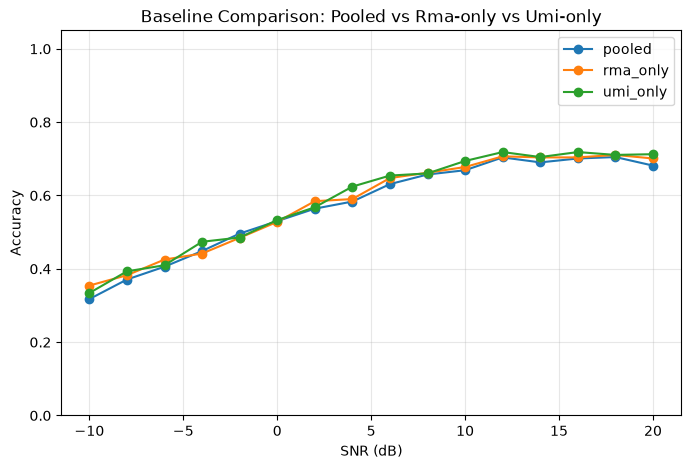

In [23]:
plot_accuracy_vs_snr_comparison(
    results,
    title="Baseline Comparison: Pooled vs Rma-only vs Umi-only"
);

## 18. Confusion Matrices + accuracy vs SNR for rma only and umi only

<Axes: title={'center': 'Rma-only — Test Confusion Matrix'}, xlabel='Predicted', ylabel='True'>

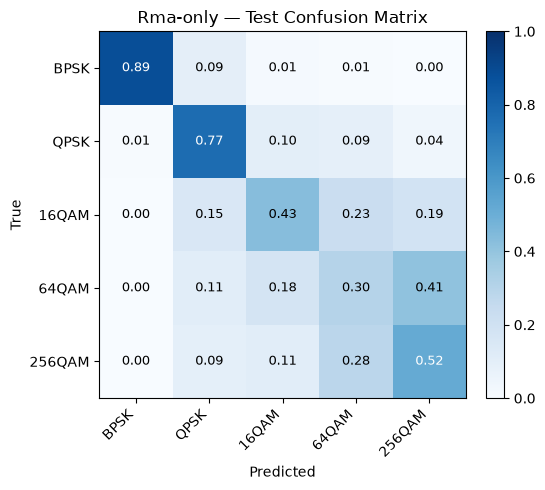

In [26]:
mod_true_rma, mod_pred_rma, snr_rma = results["rma_only"]
mod_true_umi, mod_pred_umi, snr_umi = results["umi_only"]

plot_confusion_matrix(mod_true_rma, mod_pred_rma, title="Rma-only — Test Confusion Matrix")

<Axes: title={'center': 'Umi-only — Test Confusion Matrix'}, xlabel='Predicted', ylabel='True'>

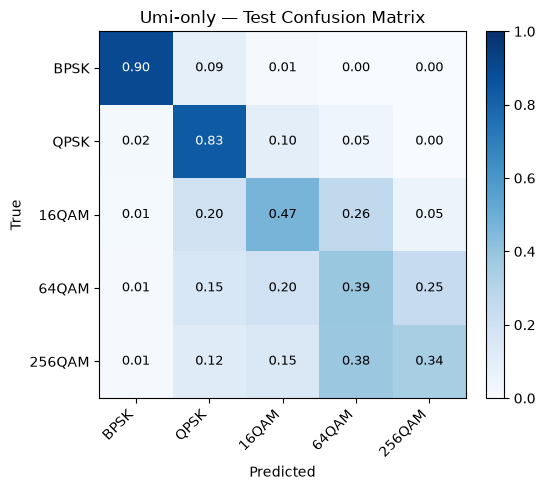

In [27]:
plot_confusion_matrix(mod_true_umi, mod_pred_umi, title="Umi-only — Test Confusion Matrix")

<Axes: title={'center': 'Rma-only — Accuracy vs SNR'}, xlabel='SNR (dB)', ylabel='Accuracy'>

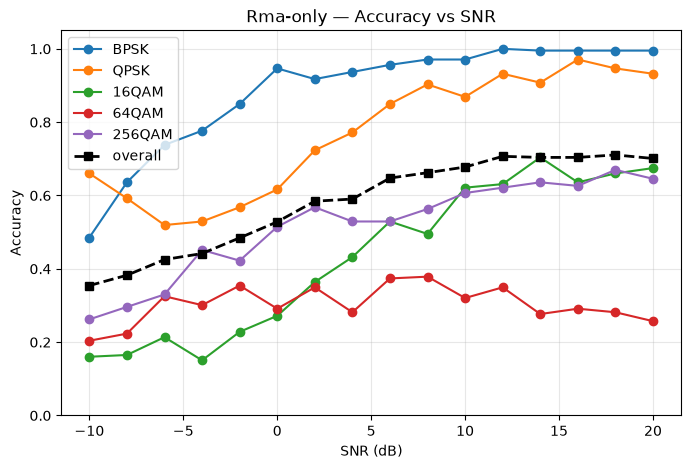

In [28]:
plot_accuracy_vs_snr(mod_true_rma, mod_pred_rma, snr_rma, title="Rma-only — Accuracy vs SNR")

<Axes: title={'center': 'Umi-only — Accuracy vs SNR'}, xlabel='SNR (dB)', ylabel='Accuracy'>

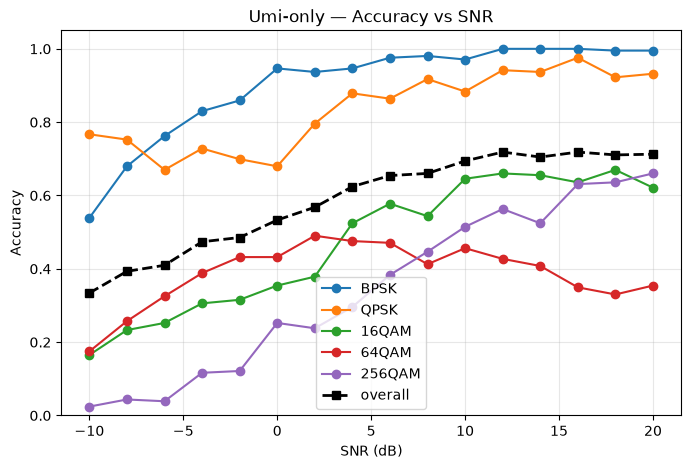

In [29]:
plot_accuracy_vs_snr(mod_true_umi, mod_pred_umi, snr_umi, title="Umi-only — Accuracy vs SNR")

## 19. Numeric output - overall accuracy by SNR, all three side by side

In [30]:
table_pooled = accuracy_vs_snr_table(*results["pooled"])
table_rma    = accuracy_vs_snr_table(*results["rma_only"])
table_umi    = accuracy_vs_snr_table(*results["umi_only"])

snr_levels = sorted(table_pooled["overall"].keys())

print(f"{'SNR':>6} | {'pooled':>8} | {'rma_only':>8} | {'umi_only':>8}")

for s in snr_levels:
    print(f"{s:6.1f} | {table_pooled['overall'][s]:8.3f} | {table_rma['overall'][s]:8.3f} | {table_umi['overall'][s]:8.3f}")

   SNR |   pooled | rma_only | umi_only
 -10.0 |    0.317 |    0.354 |    0.334
  -8.0 |    0.371 |    0.383 |    0.393
  -6.0 |    0.406 |    0.425 |    0.410
  -4.0 |    0.449 |    0.442 |    0.474
  -2.0 |    0.496 |    0.484 |    0.485
   0.0 |    0.530 |    0.528 |    0.533
   2.0 |    0.564 |    0.584 |    0.568
   4.0 |    0.583 |    0.590 |    0.624
   6.0 |    0.631 |    0.648 |    0.654
   8.0 |    0.657 |    0.662 |    0.660
  10.0 |    0.669 |    0.678 |    0.694
  12.0 |    0.704 |    0.707 |    0.718
  14.0 |    0.690 |    0.704 |    0.705
  16.0 |    0.701 |    0.704 |    0.718
  18.0 |    0.705 |    0.711 |    0.711
  20.0 |    0.682 |    0.701 |    0.713


In [31]:
print("=== POOLED ===")

high_snr_confusion(*results["pooled"])

=== POOLED ===
n=3090 samples at SNR>=15.0
            BPSK    QPSK   16QAM   64QAM  256QAM
    BPSK   0.997   0.003   0.000   0.000   0.000
    QPSK   0.000   0.961   0.023   0.002   0.015
   16QAM   0.000   0.028   0.576   0.139   0.257
   64QAM   0.000   0.016   0.126   0.126   0.731
  256QAM   0.000   0.019   0.070   0.092   0.819


array([[0.99676375, 0.00323625, 0.        , 0.        , 0.        ],
       [0.        , 0.96116505, 0.02265372, 0.00161812, 0.01456311],
       [0.        , 0.02750809, 0.57605178, 0.13915858, 0.25728155],
       [0.        , 0.01618123, 0.12621359, 0.12621359, 0.73139159],
       [0.        , 0.01941748, 0.06957929, 0.09223301, 0.81877023]])